# PDE test cases

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes.experimental.approximation import (
    ConcatBasis,
    ConstrainedBasis,
    FunctionSpace,
    LagrangeBasis,
    OrthogonalPolynomialBasis,
)
from archimedes.measure import LegendreMeasure, UnitInterval
from archimedes.quadrature import quadint

## Problem A: nonlinear spectral Galerkin BVP

$$-u''(x) + u(x)^3 = f(x), \qquad x \in [-1, 1], \qquad u(-1) = u(1) = 0$$

on a global Legendre basis. To check the discretization against something exact, we
pick a manufactured solution $u(x) = 1 - x^2$ and solve for the forcing $f$ that
makes it exact: $f = -u'' + u^3 = 2 + (1-x^2)^3$. A correct solver should recover
$u(x) = 1-x^2$ to (near) machine precision, since it's a degree-2 polynomial and
therefore exactly representable in the basis.

The basis is modal, so `boundary_dofs()` is `(None, None)` -- there's no coefficient
that *is* a boundary value. We use the tau method instead: test the strong-form
residual against every mode via `space_a.basis_matrix().T @ r(x)`, then overwrite the
two highest-degree mode equations with the Dirichlet constraints, evaluated directly
through `u(x_bc)`.

In [2]:
n_basis = 12
space_a = FunctionSpace.legendre(n_basis, a=-1.0, b=1.0)

print("boundary_dofs() for a modal basis:", space_a.basis.boundary_dofs())


def u_exact_a(x):
    return 1 - x**2


def f_manufactured_a(x):
    u_pp = -2 * np.ones_like(x)
    return -u_pp + u_exact_a(x) ** 3

boundary_dofs() for a modal basis: (None, None)


In [7]:
Phi = space_a.basis_matrix()
x = Phi.nodes
u0_a = space_a.function()

def residual_a(c):
    u = u0_a.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    r_val = -u(x, deriv=2) + u(x) ** 3 - f_manufactured_a(x)

    # Galerkin projection of the residual onto the basis functions, giving the
    # coefficients of the residual vector.
    r = Phi.T @ r_val

    # Tau method: replace the top two (highest-mode) equations with the BCs.
    r[-1] = u(np.array([1.0]))[0]
    r[-2] = u(np.array([-1.0]))[0]
    return r


c0_a = u0_a.coefficients
c_sol_a = arc.optimize.root(residual_a, c0_a)
u_sol_a = u0_a.replace(coefficients=c_sol_a)

x_check_a = np.linspace(-1, 1, 9)
err_a = np.max(np.abs(u_sol_a(x_check_a) - u_exact_a(x_check_a)))
print(f"max |u_h - u_exact| on check grid: {err_a:.3e}")

max |u_h - u_exact| on check grid: 1.050e-13


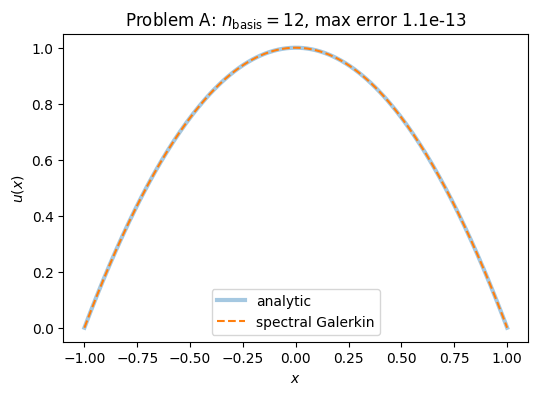

In [8]:
x_plot_a = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_a, u_exact_a(x_plot_a), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_a, u_sol_a(x_plot_a), "--", label="spectral Galerkin")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Problem A: $n_{{\\mathrm{{basis}}}}={n_basis}$, max error {err_a:.1e}")
ax.legend()
plt.show()

## Problem B: nonlinear FEM Poisson

$$-\big((1+u(x)^2)\,u'(x)\big)' = f(x), \qquad x \in [0, 1], \qquad u(0) = u(1) = 0$$

on a `PiecewiseBasis` of quadratic Lagrange elements with $C^0$ continuity. Piecewise
polynomial elements don't have a meaningful strong-form second derivative at element
boundaries, so this is discretized in *weak* (variational) form via integration by
parts: multiply by a test function $v$ and integrate,

$$\int (1+u^2)\,u'\,v'\,dx = \int f\,v\,dx,$$

which is exactly `space_b.basis_matrix(deriv=1).T @ r(x)` on both sides -- testing
against the *derivative* of the basis rather than the basis itself, since the
derivative is what survived the integration by parts.

Manufactured solution: $u(x) = x(1-x)$, giving
$f(x) = -\big[2u\,(u')^2 + (1+u^2)\,u''\big]$ with $u'=1-2x$, $u''=-2$.

Unlike Problem A, this basis is nodal: `boundary_dofs()` (just fixed on
`PiecewiseBasis` -- it previously always returned `(None, None)`, even under
`continuity=0` with an element basis that has well-defined endpoint DOFs) gives the
exact global coefficient indices for $u(0)$ and $u(1)$, so Dirichlet is a direct row
replacement, no tau-style bookkeeping required.

In [10]:
breakpoints = np.linspace(0.0, 1.0, 11)  # 10 elements
space_b = FunctionSpace.piecewise("lagrange", 3, breakpoints)  # quadratic

left, right = space_b.basis.boundary_dofs()
print(f"boundary_dofs() for the tiled/assembled basis: ({left}, {right})")
print(f"n_basis = {space_b.n_basis}")


def u_exact_b(x):
    return x * (1 - x)


def k_coef(u):
    return 1 + u**2


def f_manufactured_b(x):
    u = u_exact_b(x)
    u_p = 1 - 2 * x
    u_pp = -2 * np.ones_like(x)
    return -(2 * u * u_p**2 + k_coef(u) * u_pp)

boundary_dofs() for the tiled/assembled basis: (0, 20)
n_basis = 21


In [11]:
Phi = space_b.basis_matrix()
dPhi = space_b.basis_matrix(deriv=1)
x = Phi.nodes
u0_b = space_b.function()

def residual_b(c):
    u = u0_b.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    # and then project onto the test functions (Galerkin projection) to
    # get the residual coefficients.
    lhs = dPhi.T @ (k_coef(u(x)) * u(x, deriv=1))
    rhs = Phi.T @ f_manufactured_b(x)
    r = lhs - rhs
    # Essential (Dirichlet) BCs: the boundary DOF's coefficient *is* the value.
    r[left] = c[left] - 0.0
    r[right] = c[right] - 0.0
    return r


c0_b = np.zeros(space_b.n_basis)
c_sol_b = arc.optimize.root(residual_b, c0_b)
u_sol_b = u0_b.replace(coefficients=c_sol_b)

x_check_b = np.linspace(0, 1, 11)
err_b = np.max(np.abs(u_sol_b(x_check_b) - u_exact_b(x_check_b)))
print(f"max |u_h - u_exact| on check grid: {err_b:.3e}")

max |u_h - u_exact| on check grid: 5.551e-17


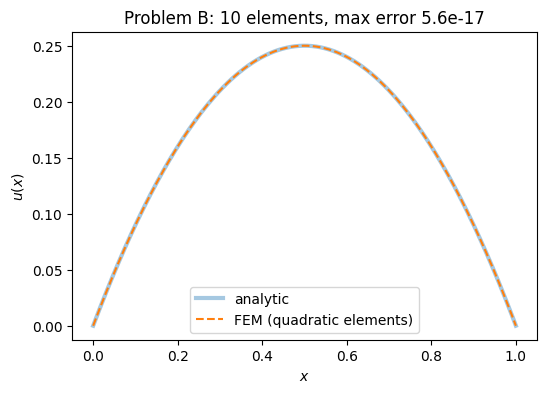

In [12]:
x_plot_b = np.linspace(0, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_b, u_exact_b(x_plot_b), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_b, u_sol_b(x_plot_b), "--", label="FEM (quadratic elements)")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Problem B: {space_b.basis.n_elements} elements, max error {err_b:.1e}")
ax.legend()
plt.show()

## Problem C: a stress test for the BC layer

$$-u''(x) + u(x)^2 = f(x), \qquad x \in [-1, 1], \qquad u'(-1) = g_L, \qquad
\int_{-1}^1 u(x)\,dx = 0$$

Problems A and B were "deliberately similar in structure" (per the intro) so that
the *basis* dispatch (modal vs. nodal) could be compared directly -- but that also
means they share exactly one BC topology: two Dirichlet conditions, one per
endpoint. That's the only shape `boundary_dofs()` (a left/right pair) and
`apply_bcs()` (one condition per end, replacing that end's row) were ever tested
against. This problem is chosen to be structurally different in exactly the way that
matters here, rather than just cosmetically:

- **`u'(-1) = g_L` is a Neumann condition**, not a value -- `DirichletBC`'s `deriv`
  field can express it, but it isn't a value at a `boundary_dofs()` slot.
- **The zero-mean constraint isn't associated with an endpoint at all.** It's a
  global integral over the whole domain. There is no "which end does this belong to"
  question to ask `boundary_dofs()` -- it doesn't have a slot for this by
  construction, not by omission.

(A 4th-order operator -- needing two conditions per end -- would be a cleaner
demonstration of `boundary_dofs()`'s 2-tuple shape specifically breaking, but that
needs a Hermite-type basis with derivative DOFs, which isn't implemented yet. This
problem instead stresses the *other* assumption `apply_bcs()` makes: that every
condition is *some* value at *some* point.)

Manufactured solution $u(x) = x^3 + x^2 - 2x - \tfrac13$ has zero mean on $[-1, 1]$
(the odd terms integrate to zero by symmetry, and $x^2 - \tfrac13$ was chosen
specifically so its mean is zero too), and $u'(-1) = -1$, giving $g_L = -1$ and
$f(x) = -(6x + 2) + u(x)^2$.

In [13]:
n_basis_c = 12
space_c = FunctionSpace.legendre(n_basis_c, a=-1.0, b=1.0)

g_left = -1.0  # u'(-1)


def u_exact_c(x):
    return x**3 + x**2 - 2 * x - 1 / 3


def f_manufactured_c(x):
    u_pp = 6 * x + 2
    return -u_pp + u_exact_c(x) ** 2
    

Phi = space_c.basis_matrix()
x = Phi.nodes
u0_c = space_c.function()

def residual_c(c):
    u = u0_c.replace(coefficients=c)

    # Evaluate the residual at the quadrature nodes (pointwise expression)
    r_val = -u(x, deriv=2) + u(x) ** 2 - f_manufactured_c(x)

    # Galerkin projection of the residual onto the basis functions, giving the
    # coefficients of the residual vector.
    r = Phi.T @ r_val

    # Neither condition is a `boundary_dofs()` value, so there's no dispatch
    # to reuse -- borrow the top two (tau) rows directly by hand.
    r[-1] = u(np.array([-1.0]), deriv=1)[0] - g_left
    r[-2] = u.integrate(-1.0, 1.0)  # zero-mean constraint
    return r


c0_c = np.zeros(space_c.n_basis)
c_sol_c = arc.optimize.root(residual_c, c0_c)
u_sol_c = u0_c.replace(coefficients=c_sol_c)

x_check_c = np.linspace(-1, 1, 9)
err_c = np.max(np.abs(u_sol_c(x_check_c) - u_exact_c(x_check_c)))
print(f"max |u_h - u_exact| on check grid: {err_c:.3e}")

max |u_h - u_exact| on check grid: 6.106e-16


In [14]:
x_c, w_c = space_c.quadrature()
via_dot = np.dot(w_c, u_sol_c(x_c))
via_integral = quadint(u_sol_c, -1.0, 1.0)
print(
    f"zero mean, np.dot(w, u(x)) vs. quadint(u, -1, 1): {via_dot:.3e} vs. {via_integral:.3e}"
)

zero mean, np.dot(w, u(x)) vs. quadint(u, -1, 1): -8.327e-17 vs. -7.286e-16


## Sturm-Liouville eigenvalue problem

$$-u''(x) = \lambda\, u(x), \qquad x \in [-1, 1], \qquad u(-1) = u(1) = 0$$

A linear eigenvalue problem, not a BVP: `arc.optimize.root` doesn't apply, and
`scipy.linalg.eig` on a generalized (mass/stiffness) matrix pencil does. The
analytic spectrum is known exactly, $\lambda_n = (n\pi/2)^2$ with
$u_n(x) = \sin(n\pi(x+1)/2)$, so every discretization below can be checked
against it directly.

This problem is chosen because eigenvalue problems expose a failure mode that
a plain BVP (Problems A-C) does not. Boyd (Ch. 7/15, citing Gottlieb-Orszag
and Dawkins-Dunbar-Douglass) distinguishes two kinds of bad eigenvalues from a
spectral discretization:

- **Numerically spurious** -- just under-resolved; the upper half of a
  truncated spectral series is never trustworthy regardless of the equation
  (Rule-of-Thumb 8, the "N/2 rule").
- **Physically spurious** -- wrong because the boundary conditions were
  *misapplied* in the discretization, not because of resolution. This class
  is specific to **generalized eigenproblems in non-periodic geometry**.

The tau method -- assemble on the full modal basis, then overwrite the last
two equations with the BCs, exactly as Problems A and C do for a BVP -- hits
the second failure mode here in a way it doesn't for a BVP: the two
overwritten rows carry no $\lambda$, so the corresponding rows of the mass
matrix $M$ become identically zero. $M$ is then singular, and the
generalized eigenproblem has literal infinite eigenvalues along those
directions -- a structural artifact of the discretization, not something more
resolution fixes.

`ConstrainedBasis.dirichlet` is the generic form of what Boyd calls the
"Heinrichs basis" -- a basis recombination that satisfies the homogeneous BC
by construction, so every equation is a genuine Galerkin equation and there
are no rows to sacrifice. We compare three routes to the same eigenproblem:

1. **Tau**: full `FunctionSpace.legendre(n)`, row-replaced -- expect exactly
   two infinite eigenvalues (physically spurious) plus a numerically-spurious
   upper half (Rule-of-Thumb 8).
2. **Basis recombination**: `ConstrainedBasis.dirichlet` -- a clean
   `(n-2)`-dimensional generalized eigenproblem with nothing to filter.
3. **Static condensation via `ConcatBasis`**: assemble on `ConcatBasis((vertex,
   bubble))` (the full `n`-dimensional vertex+bubble space), then use
   `boundary_dofs()` to mechanically eliminate the two known-zero vertex rows
   and columns -- a different, more general route (it extends to
   *inhomogeneous* Dirichlet data) that should land on exactly the same
   reduced eigenproblem as (2).

In [ ]:
n_basis = 12


def lambda_exact(n):
    return (n * np.pi / 2) ** 2


n_modes = np.arange(1, 7)
print("analytic lambda_n = (n*pi/2)^2:", lambda_exact(n_modes))

analytic lambda_n = (n*pi/2)^2: [ 2.4674011   9.8696044  22.2066099  39.4784176  61.68502751 88.82643961]


### Route 1: tau method

Strong-form residual, matching Problems A and C's own pattern (`u(x,
deriv=2)` evaluated directly on the modal basis, no integration by parts):
$K_{ij} = \int \phi_i\,(-\phi_j'')\,dx$, $M_{ij} = \int \phi_i\,\phi_j\,dx$.
Then overwrite the top two rows of *both* matrices with the Dirichlet
conditions -- the same row-replacement idiom Problems A and C use for a
residual vector, applied here to the matrix pencil itself.

In [ ]:
from scipy import linalg

space_tau = FunctionSpace.legendre(n_basis, a=-1.0, b=1.0)
Phi = space_tau.basis_matrix()
d2Phi = space_tau.basis_matrix(deriv=2)

K_tau = Phi.T @ (-d2Phi.matrix)
M_tau = Phi.T @ Phi

phi_left = space_tau.basis.evaluate(np.array([-1.0]), a=-1.0, b=1.0)[0]
phi_right = space_tau.basis.evaluate(np.array([1.0]), a=-1.0, b=1.0)[0]
K_tau[-2], M_tau[-2] = phi_left, 0.0
K_tau[-1], M_tau[-1] = phi_right, 0.0

eigvals_tau = np.sort_complex(linalg.eig(K_tau, M_tau, right=False))
n_inf = np.sum(~np.isfinite(eigvals_tau.real))
print(f"tau: {n_inf} infinite eigenvalue(s) (physically spurious, from the")
print("     singular mass matrix rows introduced by row-replacement)")
print()
finite_tau = np.sort(eigvals_tau[np.isfinite(eigvals_tau.real)].real)
print("finite tau eigenvalues, sorted:")
print(finite_tau)
print()
print("error vs analytic (first 6, numerically spurious after ~n/2):")
print(np.abs(finite_tau[:6] - lambda_exact(n_modes)))

tau: 2 infinite eigenvalue(s) (physically spurious, from the
     singular mass matrix rows introduced by row-replacement)

finite tau eigenvalues, sorted:
[   2.4674011     9.8696044    22.20665782   39.47949651   62.11157983
   90.29455634  154.71016193  218.73339568 1243.50419932 1786.62294706]

error vs analytic (first 6, numerically spurious after ~n/2):
[1.86517468e-14 2.53864485e-10 4.79143576e-05 1.07891004e-03
 4.26552324e-01 1.46811673e+00]


### Route 2: basis recombination (`ConstrainedBasis.dirichlet`)

Same weak ingredients, but the trial/test space is the `(n-2)`-dimensional
Dirichlet-satisfying subspace directly -- every basis function already
vanishes at $\pm 1$, so there is no BC row to add or replace; the assembled
system is genuine (symmetric) Galerkin throughout.

In [ ]:
legendre_basis = OrthogonalPolynomialBasis(LegendreMeasure(), n_basis)
bubble = ConstrainedBasis.dirichlet(legendre_basis)
space_bubble = FunctionSpace(bubble, UnitInterval.Parameters(a=-1.0, b=1.0))

Phi_b = space_bubble.basis_matrix()
d2Phi_b = space_bubble.basis_matrix(deriv=2)
K_b = Phi_b.T @ (-d2Phi_b.matrix)
M_b = Phi_b.T @ Phi_b

eigvals_b = np.sort(linalg.eig(K_b, M_b, right=False).real)
print(f"{bubble.n_basis} eigenvalues, none infinite -- nothing to filter")
print(eigvals_b)
print()
print("error vs analytic (first 6):")
print(np.abs(eigvals_b[:6] - lambda_exact(n_modes)))

10 eigenvalues, none infinite -- nothing to filter
[  2.4674011    9.8696044   22.20661234  39.47850459  61.76067929
  89.16437778 132.9179639  181.6871226  463.14734337 642.30039063]

error vs analytic (first 6):
[1.28785871e-14 4.49773552e-12 2.44177672e-06 8.69849598e-05
 7.56517828e-02 3.37938174e-01]


### Route 3: static condensation (`ConcatBasis` + `boundary_dofs()`)

Assemble on the full `n`-dimensional vertex+bubble space, then use
`boundary_dofs()` to read off exactly which rows/columns are the (known,
zero) vertex values and eliminate them mechanically -- rather than needing
`ConstrainedBasis` to have built the reduced space directly. This is the
more general route: for an inhomogeneous Dirichlet condition, the same
elimination moves the vertex columns to the right-hand side instead of
dropping them, which `ConstrainedBasis` alone can't express (see the earlier
discussion of why `ConstrainedBasis` is deliberately homogeneous-only).

In [ ]:
vertex = LagrangeBasis(reference_nodes=np.array([-1.0, 1.0]))
combo = ConcatBasis((vertex, bubble), quad_rule=legendre_basis.default_quadrature())
space_combo = FunctionSpace(combo, UnitInterval.Parameters(a=-1.0, b=1.0))

Phi_c = space_combo.basis_matrix()
d2Phi_c = space_combo.basis_matrix(deriv=2)
K_c = Phi_c.T @ (-d2Phi_c.matrix)
M_c = Phi_c.T @ Phi_c

left, right = combo.boundary_dofs()
keep = [i for i in range(combo.n_basis) if i not in (left, right)]
eigvals_c = np.sort(linalg.eig(K_c[np.ix_(keep, keep)], M_c[np.ix_(keep, keep)], right=False).real)

print(f"vertex DOFs eliminated: left={left}, right={right}")
print("max diff vs basis-recombination eigenvalues:", np.max(np.abs(eigvals_c - eigvals_b)))

vertex DOFs eliminated: left=0, right=1
max diff vs basis-recombination eigenvalues: 0.0


### Comparing the two failure modes

The tau method's finite eigenvalues split cleanly into the two categories
Boyd distinguishes: the first several agree with basis recombination (and
the analytic spectrum) to many digits, then both discretizations degrade
together as mode number grows (numerically spurious, Rule-of-Thumb 8) --
*and* the tau method additionally reports two eigenvalues at infinity that
never correspond to anything physical, at any resolution.

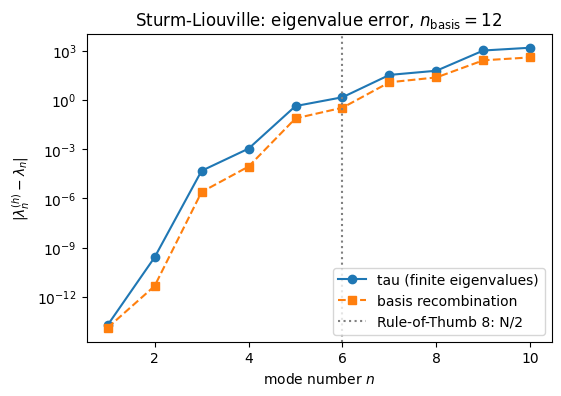

In [ ]:
n_check = min(len(finite_tau), len(eigvals_b))
mode_idx = np.arange(1, n_check + 1)
lam_ref = lambda_exact(mode_idx)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(mode_idx, np.abs(finite_tau[:n_check] - lam_ref), "o-", label="tau (finite eigenvalues)")
ax.semilogy(mode_idx, np.abs(eigvals_b[:n_check] - lam_ref), "s--", label="basis recombination")
ax.axvline(n_basis / 2, color="gray", ls=":", label="Rule-of-Thumb 8: N/2")
ax.set_xlabel("mode number $n$")
ax.set_ylabel(r"$|\lambda_n^{(h)} - \lambda_n|$")
ax.set_title(f"Sturm-Liouville: eigenvalue error, $n_{{\\mathrm{{basis}}}}={n_basis}$")
ax.legend()
plt.show()

### Conditioning: does `ConstrainedBasis` inherit Boyd's improved rate?

Boyd notes that the *specific* analytic recombination `(1-x^2)T_j` (the
"Heinrichs basis") improves the stiffness-matrix condition number from
$O(N^4)$ (a naive "difference" basis like $T_{2j} - T_0$) down to $O(N^2)$.
`ConstrainedBasis.dirichlet` instead builds an arbitrary orthonormal basis for
the same null space via SVD -- there's no reason it has to inherit that
specific analytic property, and this is worth checking empirically rather
than assuming either way.

In [ ]:
ns = [8, 16, 32, 64, 128]
conds_K, conds_M = [], []
for n in ns:
    lb = OrthogonalPolynomialBasis(LegendreMeasure(), n)
    bub = ConstrainedBasis.dirichlet(lb)
    sp = FunctionSpace(bub, UnitInterval.Parameters(a=-1.0, b=1.0))
    dP = sp.basis_matrix(deriv=1)
    P = sp.basis_matrix()
    conds_K.append(np.linalg.cond(dP.T @ dP))
    conds_M.append(np.linalg.cond(P.T @ P))

conds_K = np.array(conds_K)
conds_M = np.array(conds_M)
doubling_slope = np.log(conds_K[1:] / conds_K[:-1]) / np.log(2)

print("n:            ", ns)
print("cond(K):      ", conds_K)
print("cond(M):      ", conds_M)
print("log2 doubling ratio of cond(K):", doubling_slope)
print("(~2 => O(n^2) like Heinrichs' basis; ~4 => O(n^4) like a naive difference basis)")

n:             [8, 16, 32, 64, 128]
cond(K):       [5.78067353e+01 7.77893114e+02 1.15193443e+04 1.77940038e+05
 2.80009588e+06]
cond(M):       [1. 1. 1. 1. 1.]
log2 doubling ratio of cond(K): [3.75026243 3.88834285 3.94926067 3.97601316]
(~2 => O(n^2) like Heinrichs' basis; ~4 => O(n^4) like a naive difference basis)


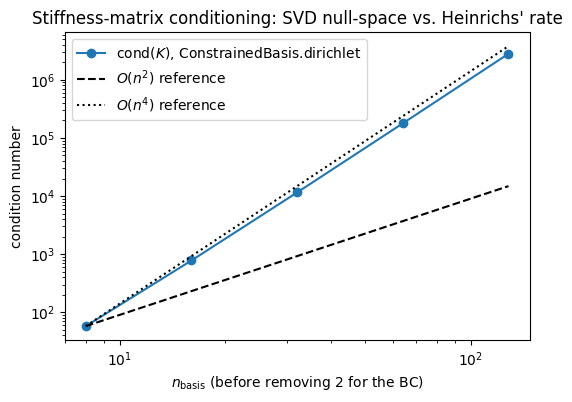

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.loglog(ns, conds_K, "o-", label=r"cond($K$), ConstrainedBasis.dirichlet")
ns_arr = np.array(ns, dtype=float)
ax.loglog(ns_arr, conds_K[0] * (ns_arr / ns_arr[0]) ** 2, "k--", label=r"$O(n^2)$ reference")
ax.loglog(ns_arr, conds_K[0] * (ns_arr / ns_arr[0]) ** 4, "k:", label=r"$O(n^4)$ reference")
ax.set_xlabel("$n_{\\mathrm{basis}}$ (before removing 2 for the BC)")
ax.set_ylabel("condition number")
ax.set_title("Stiffness-matrix conditioning: SVD null-space vs. Heinrichs' rate")
ax.legend()
plt.show()

## Further test problems

Problems A-C exercise the *shape* of a boundary condition (an endpoint value, an
endpoint derivative, a global constraint) but they're all still 1D, steady, and
scalar-valued. Here's a broader menu, organized by what each one would actually
stress in the design, with a rough read on what's already supported versus what
would need new work.

### Boundary conditions

- **Pure Neumann** ($u'(0) = u'(1) = 0$, no Dirichlet at all). The stiffness matrix
  has a nontrivial null space (the constant function), so the linear system is
  singular unless something pins the mean -- a genuinely different failure mode from
  Problem C's zero-mean *constraint*, since here nothing forces uniqueness unless you
  add it yourself.
- **Robin/mixed** ($a\,u(x_b) + b\,u'(x_b) = g$). Cheap to try -- one row,
  `a*u(x_b) + b*u(x_b, deriv=1) - g`, the same mechanism as Problem C's Neumann row
  but with both terms present at once.
- **Interior interface/jump conditions** -- two materials meeting at a breakpoint,
  continuous value but a flux jump ($k_1 u_1' \neq k_2 u_2'$). `PiecewiseBasis`
  already has breakpoints and one-sided (`side=`) evaluation, originally built for DG
  numerical fluxes -- untested so far for an *interior essential condition* rather
  than a domain-boundary one.
- **Periodic.** Not supported today: there's no `FourierBasis` anywhere in the
  module, and `PiecewiseBasis`'s continuity assembly only merges *interior*
  breakpoints, never wraps the first DOF back to the last. Would need real new work
  -- either a genuine Fourier basis, or a periodic "wrap" option on `PiecewiseBasis`.

### Different mathematical structure

- **Sturm-Liouville eigenvalue problem** -- done, see "Sturm-Liouville eigenvalue
  problem" above. Tau-style row replacement does misbehave exactly the way Boyd
  warns (two literal infinite eigenvalues from a singularized mass matrix, on top
  of the ordinary Rule-of-Thumb-8 numerically-spurious upper half); basis
  recombination (`ConstrainedBasis.dirichlet`) and static condensation via
  `ConcatBasis` both avoid it and agree with each other to machine precision.
- **Coupled/vector-valued system** (a two-species reaction-diffusion pair, or a
  linear-elasticity bar) -- exercises `BasisExpansion`'s vector-valued coefficients
  (`(n_basis, m)`) with *different* boundary conditions per component. Row-splicing
  becomes 2D: which `(dof, component)` pairs get overridden.
- **Singularly perturbed convection-diffusion** ($-\epsilon u'' + u' = f$, small
  $\epsilon$) -- a classic boundary-layer problem (Boyd's Rule 6). Also the case that
  actually *needs* mismatched trial/test derivative orders ($\int u' v\,dx$), rather
  than that being hypothetical.
- **4th-order / beam bending** ($u'''' = f$) -- genuinely not supported: needs
  $C^1$ continuity, which needs Hermite-type elements with derivative DOFs that
  don't exist yet.
- **Blasius** (semi-infinite, nonlinear, 3rd-order) -- exercises the barely-tested
  `HalfLine`/Laguerre combination.

### Discontinuous Galerkin

A linear advection equation ($u_t + c\,u_x = 0$) via DG on `continuity=-1` elements
with an upwind numerical flux at each interface, built from $u^-$/$u^+$ via
`side="left"`/`"right"` evaluation. `PiecewiseBasis` explicitly documents two-sided
access as built for exactly this -- and nothing built so far has actually assembled
one.

### Transient

- **Heat equation** (linear parabolic) -- method of lines: assemble
  `mass_matrix`/`stiffness_matrix` once, hand $M\dot u = -Ku + f$ to
  `arc.simulate.odeint`. The cheapest way to test that `approximation` composes with
  `simulate`, which nothing so far has done.
- **Wave equation** -- same MOL approach, first-order-in-time reduction, hyperbolic
  instead of parabolic.
- **Viscous Burgers'** -- nonlinear flux plus diffusion, a smooth traveling shock
  layer with known structure. Combines nonlinear residual assembly *and*
  time-stepping in one problem, and on a spectral/`TensorBasis` space would be the
  first thing here to touch dealiasing.

### Candidates for next

1. **DG advection** -- newest, most purpose-built part of the design, currently
   untested.
2. **Heat equation via method of lines** -- cheap, and validates composability with
   `simulate` for the first time.
3. **Interior interface/jump condition** on the FEM problem -- nearly free given
   `side=` already exists.
